# Quick test of automated segmentation of power doppler data


In [3]:
%load_ext autoreload
%autoreload 2
from nilearn import plotting


import nilearn as nl
import matplotlib.pyplot as plt
import numpy as np
import nibabel as nib
import os
import pandas as pd
import re

from nilearn.glm.first_level import make_first_level_design_matrix
from nilearn.plotting import plot_design_matrix

from ucla_fusi_utils import DirectoryManager
import ucla_fusi_utils as utils


from pathlib import Path
from datetime import datetime, timedelta




The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


ModuleNotFoundError: No module named 'ucla_fusi_utils'

In [4]:
# define arguements to specify the data to be processed
base_path=Path('/Users/taflalo/Data/UCLA/2024-04-19/UCLA-003/ses-2024-04-19/run-03')
sequence = 'seq-RF_5000000Hz_5a_3c_2rp_25Dmin_55Dmax_4el_TGC0ini_100end_1000Tdur_-1Gain_3AFE_200loops'


event_time_offset = 3  # Offset in seconds to apply to stimulus onsets. This can be used to correct for differences between when the instruction is given and when the stimulus is presented.
apply_image_registration=True # If true, we will register the fUSi data to the first frame. If false, we will not register the fUSi data.
time_zone_offset=7

dm = DirectoryManager(base_path, sequence)
dm.list_acquisition_directories()


NameError: name 'Path' is not defined

In [5]:
# If beamforming and power doppler have not been performed, perform them using the following commands in your terminal (make sure mangrove is activated!)
# Command to execute the mangrove raw data to beamformed conversion
beamform_command =  f'python -m mangrove.io.convert.mangrove_raw_data_to_beamformed input_mode=experiments_root_folder input_mode.experiments_root_folder="{dm.sequence_data_path}"'
power_doppler_command =  f'python -m mangrove.io.convert.beamformed_to_doppler input_mode=experiments_root_folder input_mode.experiments_root_folder="{dm.sequence_data_path}"'

print(beamform_command)
print(power_doppler_command)

NameError: name 'dm' is not defined

In [62]:
# Create the events data structure to create a design matrix
fusi_info=utils.load_fUSi_info(dm.power_doppler_path)
fusi_data = utils.get_fusi_frames(dm.power_doppler_path, fusi_info, -1)


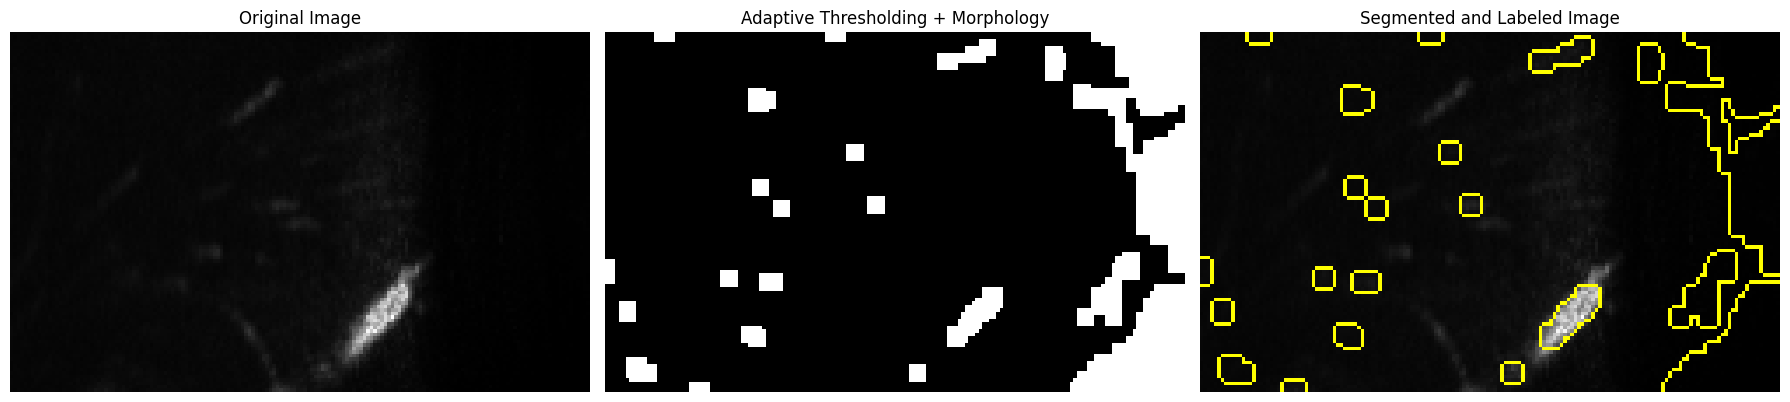

In [69]:
import cv2
from skimage import measure, segmentation  # Correct imports for labeling and segmentation

gray_image=fusi_data[:, 0, :, 0]
gray_image=gray_image-np.mean(gray_image)
# Convert image to numpy array suitable for OpenCV processing
opencv_image = np.array(gray_image)

# Normalize the image to 0-255 range
opencv_image = cv2.normalize(opencv_image, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)

# Convert to uint8
opencv_image = opencv_image.astype('uint8')

# Apply adaptive thresholding
adaptive_thresh = cv2.adaptiveThreshold(opencv_image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                        cv2.THRESH_BINARY, 23, 1)

# Morphological operations to remove noise and small objects
kernel = np.ones((3,3),np.uint8)
opening = cv2.morphologyEx(adaptive_thresh, cv2.MORPH_OPEN, kernel, iterations=2)
closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel, iterations=1)

# Label the connected components
labeled_closing, num_features_closing = measure.label(closing, return_num=True, connectivity=2, background=0)

# Visualize the processed image
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(opencv_image, cmap='gray')
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(closing, cmap='gray')
ax[1].set_title('Adaptive Thresholding + Morphology')
ax[1].axis('off')

ax[2].imshow(segmentation.mark_boundaries(opencv_image, labeled_closing), cmap='gray')
ax[2].set_title('Segmented and Labeled Image')
ax[2].axis('off')

plt.tight_layout()
plt.show()
